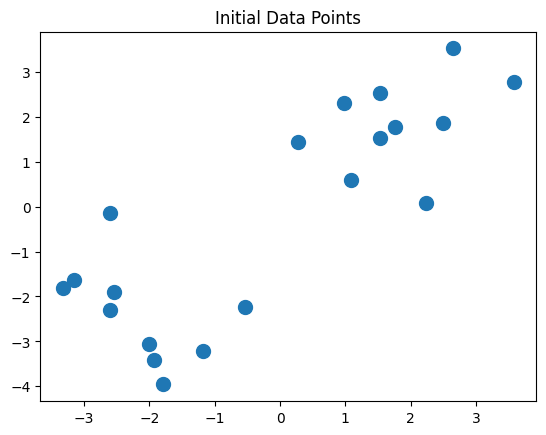

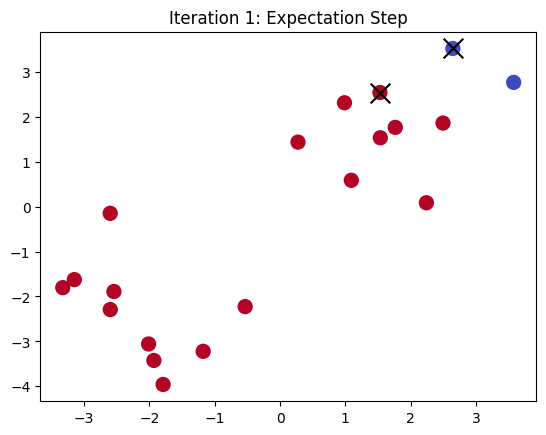

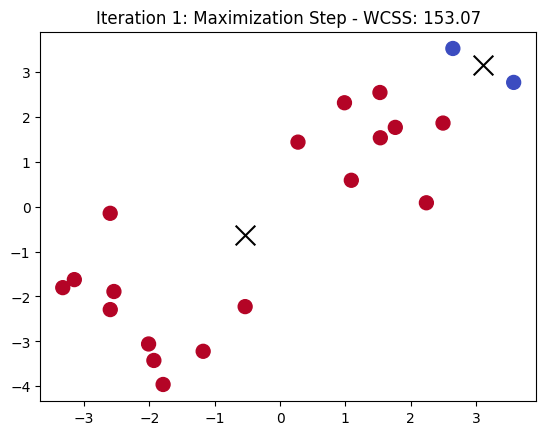

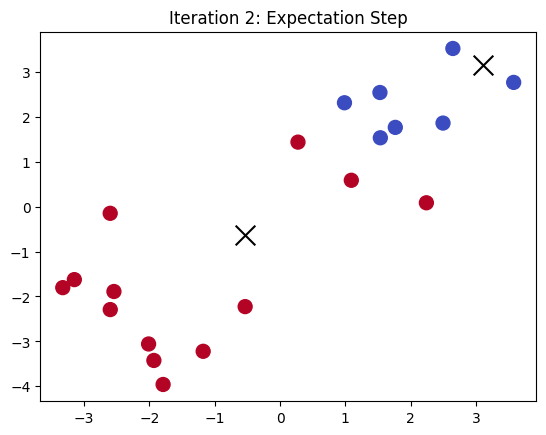

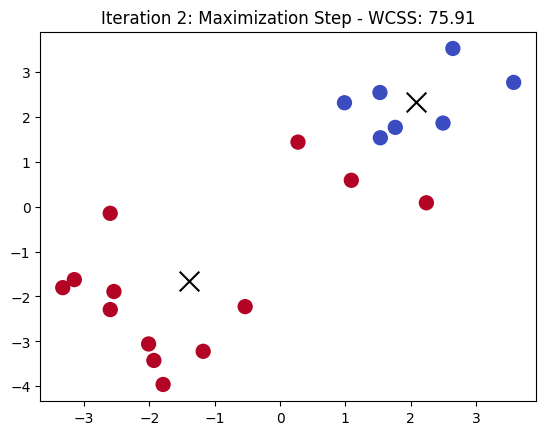

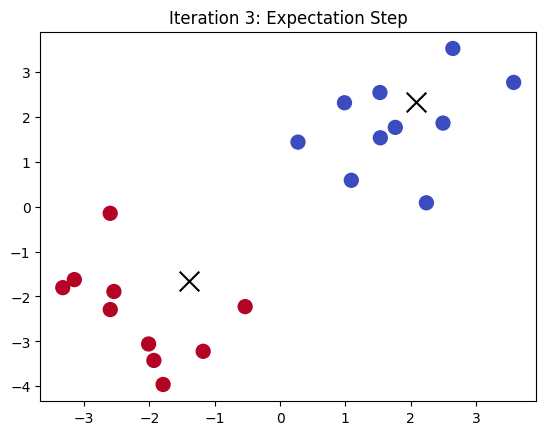

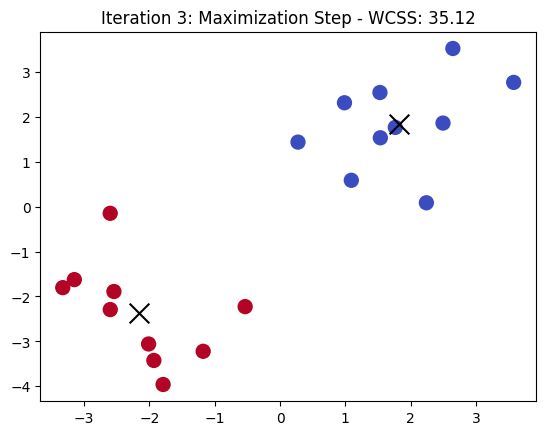

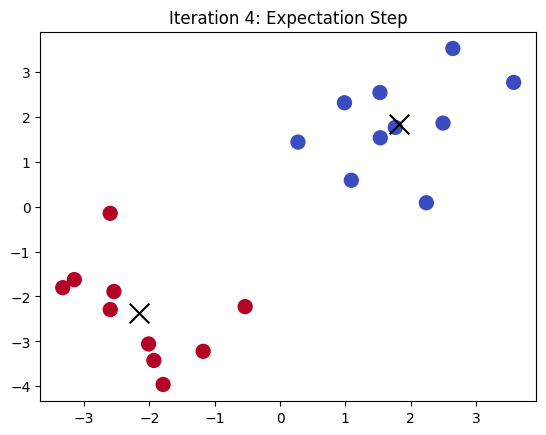

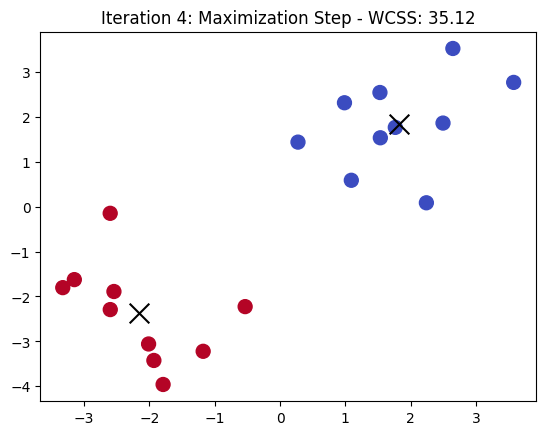

Converged after 4 iterations.


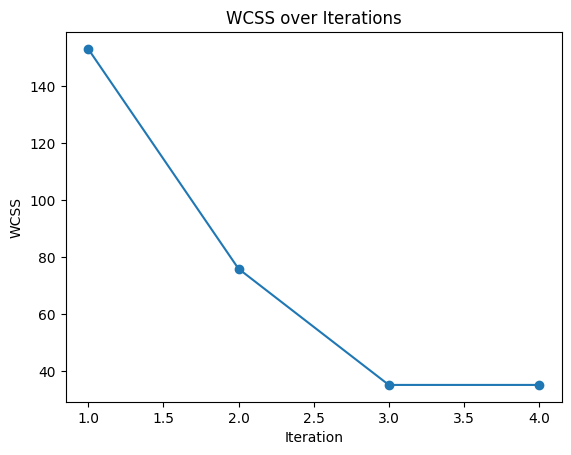

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generating random data points that can be visually clustered into two groups
np.random.seed(42)
points = np.vstack((np.random.randn(10, 2) + [2, 2], np.random.randn(10, 2) + [-2, -2]))

# Plot initial points
plt.scatter(points[:, 0], points[:, 1], s=100)
plt.title('Initial Data Points')
plt.show()

# Initialize random centroids
centroids = points[np.random.choice(points.shape[0], 2, replace=False)]

def plot_clusters(points, centroids, labels, title):
    plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='coolwarm', s=100)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='x')
    plt.title(title)
    plt.show()

def compute_wcss(points, centroids, labels):
    wcss = 0
    for i in range(centroids.shape[0]):
        wcss += np.sum((points[labels == i] - centroids[i]) ** 2)
    return wcss

def kmeans_with_wcss(points, centroids, max_iters=10):
    wcss_values = []

    for i in range(max_iters):
        # Expectation step: assign points to the closest centroid
        distances = np.linalg.norm(points[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Plot clusters after expectation step
        plot_clusters(points, centroids, labels, f'Iteration {i + 1}: Expectation Step')

        # Maximization step: compute new centroids
        new_centroids = np.array([points[labels == j].mean(axis=0) for j in range(centroids.shape[0])])

        # Compute and store WCSS after each maximization step
        wcss = compute_wcss(points, new_centroids, labels)
        wcss_values.append(wcss)

        # Plot clusters after maximization step
        plot_clusters(points, new_centroids, labels, f'Iteration {i + 1}: Maximization Step - WCSS: {wcss:.2f}')

        # Check for convergence
        if np.all(centroids == new_centroids):
            print(f"Converged after {i + 1} iterations.")
            break

        centroids = new_centroids

    # Plot the WCSS values over iterations
    plt.plot(range(1, len(wcss_values) + 1), wcss_values, marker='o')
    plt.title('WCSS over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('WCSS')
    plt.show()

# Run K-Means algorithm with WCSS tracking
centroids = points[np.random.choice(points.shape[0], 2, replace=False)]
kmeans_with_wcss(points, centroids)


### Limitations of K-Means
- **Choice of K**: The number of clusters $ K $ needs to be specified in advance.
- **Sensitivity to Initialization**: Different initial centroids can lead to different final clusters (hence methods like K-Means++ are often used to mitigate this).
- **Assumption of Spherical Clusters**: K-Means assumes that clusters are roughly spherical in shape and of similar size, which may not always be true.

---

In the next section, we will explore more advanced clustering algorithms, including **Hierarchical Clustering** and **DBSCAN**, and how they address some of the limitations of K-Means.


## Hierarchical Clustering Algorithm

### Overview of Hierarchical Clustering
Hierarchical clustering is an unsupervised learning algorithm that builds a hierarchy of clusters. Unlike **K-Means**, which requires the number of clusters $ K $ to be pre-specified, hierarchical clustering does not require this in advance. The algorithm creates a tree-like structure called a **dendrogram**, which allows you to visualize how clusters are merged or split.

There are two main types of hierarchical clustering:
- **Agglomerative (Bottom-Up)**
- **Divisive (Top-Down)**

### How Hierarchical Clustering is Different from K-Means
- **K-Means** requires the user to specify the number of clusters $ K $, whereas hierarchical clustering does not.
- In **K-Means**, clusters are updated iteratively by adjusting centroids, whereas in hierarchical clustering, clusters are formed by merging or splitting without centroids.
- Hierarchical clustering produces a hierarchy or a tree of clusters, while K-Means results in a fixed partition of the data.

---

### Types of Hierarchical Clustering

#### Agglomerative Clustering (Bottom-Up)
Agglomerative clustering starts with each data point as a separate cluster and then iteratively merges the closest pairs of clusters until only one cluster remains. The hierarchy can be cut at any point to obtain the desired number of clusters.

The steps involved in **Agglomerative Clustering**:
1. **Initialization**: Each data point is its own cluster.
2. **Compute Distances**: Compute the distance between all clusters.
3. **Merge Clusters**: Merge the two closest clusters.
4. **Update Distances**: Recompute the distances between the new cluster and all other clusters.
5. **Repeat**: Repeat steps 3 and 4 until only one cluster remains.

#### Divisive Clustering (Top-Down)
Divisive clustering starts with all data points in a single cluster and then recursively splits them into smaller clusters. The process continues until each data point is its own cluster.

---

### Distance Metrics
The distance between clusters is a crucial factor in hierarchical clustering. Common distance metrics include:
- **Euclidean Distance**: $ d(A, B) = \sqrt{\sum (a_i - b_i)^2} $
- **Manhattan Distance**: $ d(A, B) = \sum |a_i - b_i| $
- **Cosine Similarity**: Measures the cosine of the angle between two vectors.

### Linkage Criteria
Linkage criteria determine how the distance between clusters is computed:
- **Single Linkage**: Distance between two clusters is the minimum distance between any single point in one cluster and any point in the other.
  
  $$
  d(A, B) = \min_{a \in A, b \in B} \|a - b\|
  $$
  
- **Complete Linkage**: Distance between two clusters is the maximum distance between any single point in one cluster and any point in the other.

  $$
  d(A, B) = \max_{a \in A, b \in B} \|a - b\|
  $$

- **Average Linkage**: Distance between two clusters is the average distance between all points in the two clusters.

  $$
  d(A, B) = \frac{1}{|A| |B|} \sum_{a \in A} \sum_{b \in B} \|a - b\|
  $$


### Add an image to explain hierarchical clustering

In [ ]:
### Add an image to explain hierarchical clustering

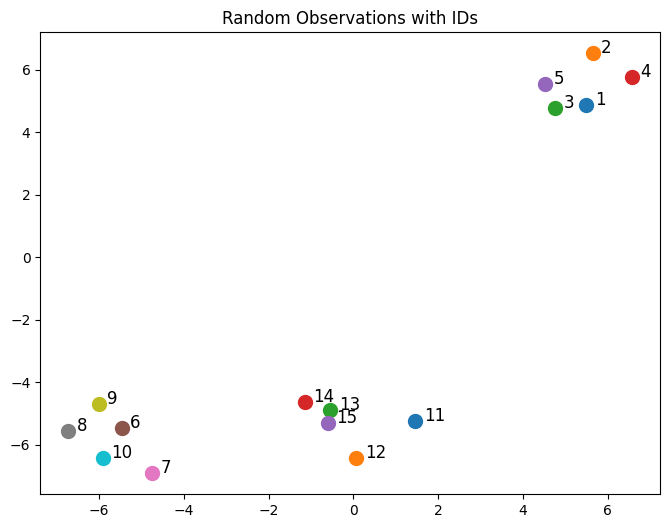

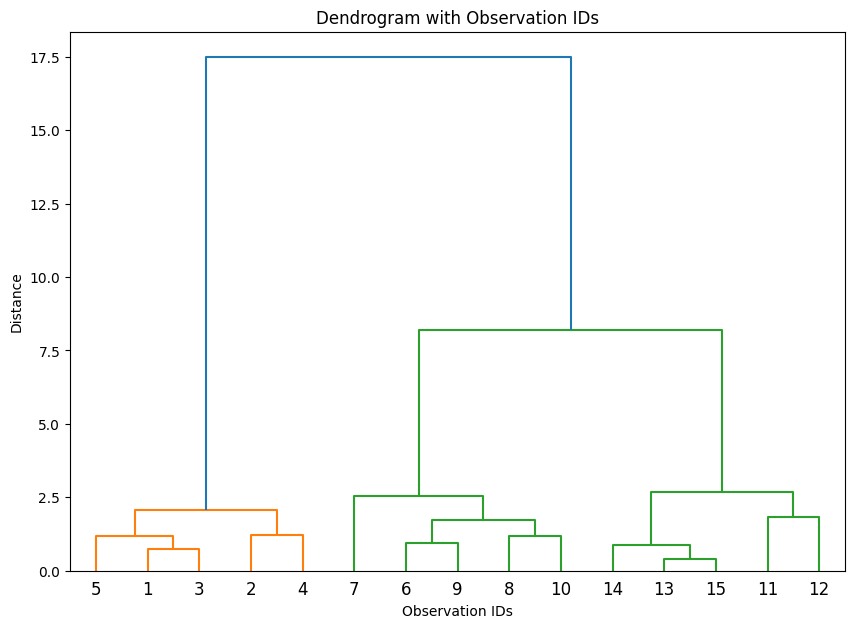

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Step 1: Generating random data points that can form 3 clusters
np.random.seed(42)
points = np.vstack((np.random.randn(5, 2) + [5, 5], np.random.randn(5, 2) + [-5, -5], np.random.randn(5, 2) + [0, -5]))

# Step 2: Number the observations to act as ids and plot them
ids = np.arange(1, points.shape[0] + 1)

plt.figure(figsize=(8, 6))
for i, point in enumerate(points):
    plt.scatter(point[0], point[1], s=100)
    plt.text(point[0] + 0.2, point[1], f'{ids[i]}', fontsize=12)
plt.title('Random Observations with IDs')
plt.show()

# Step 3: Perform hierarchical clustering (Agglomerative Clustering) using complete linkage
Z = linkage(points, method='complete')

# Step 4: Plot dendrogram with observation ids visible
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=ids)
plt.title('Dendrogram with Observation IDs')
plt.xlabel('Observation IDs')
plt.ylabel('Distance')
plt.show()


##Use Cases

### 1. **Gene Expression Data Analysis (Bioinformatics)**
In bioinformatics, hierarchical clustering is frequently used to analyze gene expression data. Gene expression studies involve measuring the activity levels of thousands of genes simultaneously across different conditions or tissues. The resulting data matrix is typically very high-dimensional, making it difficult to interpret.

Hierarchical clustering helps by:
- **Grouping genes with similar expression patterns**: Genes that behave similarly under various conditions are clustered together. This can reveal functional relationships between genes and help in identifying gene regulatory networks.
- **Classifying diseases**: In cancer research, for example, hierarchical clustering is used to identify subtypes of tumors based on their gene expression profiles. This helps in better understanding the molecular basis of the disease and can guide personalized treatment plans.

### 2. **Customer Segmentation in Marketing**
In marketing, businesses often need to segment their customers into distinct groups to better target their products and services. Hierarchical clustering can help by analyzing customer data based on several factors like purchasing behavior, demographics, or interaction data.

Hierarchical clustering helps by:
- **Discovering natural customer segments**: It doesn't require pre-defining the number of segments, allowing the marketer to explore the customer base naturally and find the optimal cut-off based on business requirements.
- **Creating a hierarchy of customer segments**: Some businesses might need a multi-level segmentation strategy. For example, customers can first be divided into high-level groups (e.g., high spenders vs. low spenders) and then into subgroups within each main group (e.g., types of products purchased). The dendrogram visualization helps in determining these subgroups efficiently.


## Principal Component Analysis (PCA)

### What is Principal Component Analysis?
Principal Component Analysis (PCA) is a dimensionality reduction technique used to transform a high-dimensional dataset into a lower-dimensional space. By doing so, it aims to capture the most significant variance in the data with fewer features, known as **principal components**. PCA is an **unsupervised learning algorithm** because it does not rely on labeled data and only uses the inherent structure of the data to identify patterns.

### Why PCA is Unsupervised
PCA does not require any target variable or output to learn the transformation. Instead, it analyzes the structure of the input data to identify new, uncorrelated features (principal components) that explain the maximum variance. As such, it falls under the category of unsupervised learning, as it finds patterns without supervision.

### Applications of PCA
- **Image Compression**: Reducing the number of dimensions in images while retaining essential information.
- **Feature Extraction**: Selecting a smaller set of features that capture the most variance, useful for speeding up other machine learning algorithms.
- **Visualization**: Reducing data to 2 or 3 dimensions for visualizing high-dimensional datasets.

---

### Steps in Principal Component Analysis

The main steps in PCA are as follows:

1. **Standardize the Data**:
   Center the data around the origin by subtracting the mean and scaling by the standard deviation.
   
   $$
   x_i' = \frac{x_i - \text{mean}(x)}{\text{std}(x)}
   $$

2. **Compute the Covariance Matrix**:
   Compute the covariance matrix for the dataset to measure how each feature relates to every other feature.
   
   $$
   \text{Cov}(X) = \frac{1}{n - 1} X^T X
   $$

3. **Calculate Eigenvalues and Eigenvectors**:
   Calculate the eigenvalues and eigenvectors of the covariance matrix. The eigenvectors represent the directions of maximum variance, and the eigenvalues represent the magnitude of variance in these directions.
   
   $$
   \text{Cov}(X)v = \lambda v
   $$

   Where:
   - $ \lambda $ represents an eigenvalue.
   - $ v $ represents an eigenvector.

4. **Select Principal Components**:
   Rank the eigenvectors by their eigenvalues (in descending order) and select the top $ k $ eigenvectors as the principal components. These components form a new basis for the data in the reduced space.

5. **Project the Data onto the Principal Components**:
   Transform the original data into the space defined by the principal components, reducing the dataset to $ k $ dimensions.
   
   $$
   X_{\text{reduced}} = X \cdot V_k
   $$

   Where $ V_k $ is the matrix of the top $ k $ eigenvectors.



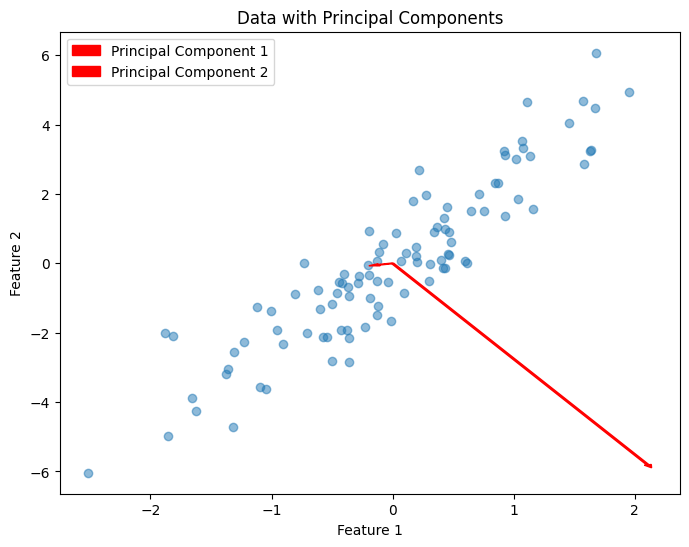

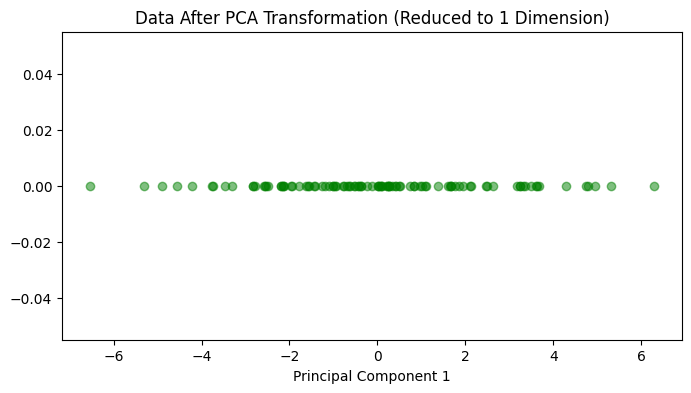

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Step 1: Generate random 2D data points that are linearly correlated
np.random.seed(42)
x = np.random.normal(0, 1, 100)
y = 2.5 * x + np.random.normal(0, 1, 100)
data = np.column_stack((x, y))

# Step 2: Standardize the data
data_centered = data - np.mean(data, axis=0)

# Step 3: Compute the Covariance Matrix
cov_matrix = np.cov(data_centered, rowvar=False)

# Step 4: Calculate Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 5: Plot original data and principal components
plt.figure(figsize=(8, 6))
plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.5)
for i in range(len(eigenvalues)):
    plt.arrow(0, 0, eigenvectors[i, 0] * eigenvalues[i], eigenvectors[i, 1] * eigenvalues[i],
              color='r', width=0.02, label=f'Principal Component {i+1}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data with Principal Components')
plt.legend()
plt.show()

# Step 6: Transform the data to the new coordinate system (2D to 1D reduction)
pca = PCA(n_components=1)
data_reduced = pca.fit_transform(data_centered)

# Step 7: Visualize the Reduced Data
plt.figure(figsize=(8, 4))
plt.scatter(data_reduced, np.zeros_like(data_reduced), alpha=0.5, color='g')
plt.title('Data After PCA Transformation (Reduced to 1 Dimension)')
plt.xlabel('Principal Component 1')
plt.show()


## Confirmatory Factor Analysis (CFA)

### What is Confirmatory Factor Analysis?
Confirmatory Factor Analysis (CFA) is a statistical technique used to test hypotheses or theories about the relationships between observed variables (measured items) and underlying latent constructs (factors). It is often used in fields such as psychology, social sciences, and marketing to confirm whether the data fits a hypothesized measurement model.

In CFA, we start with a theory or hypothesis regarding how the observed variables relate to a set of latent factors. Then, we test the model to see if it aligns with the observed data. Unlike **Exploratory Factor Analysis (EFA)**, which aims to uncover the underlying structure of data without prior assumptions, CFA assumes an existing structure and aims to confirm it.

### Why CFA is Considered an Unsupervised Learning Technique
CFA is often regarded as an **unsupervised learning** technique because it does not involve predicting an outcome variable but rather seeks to understand the relationships between measured items and latent factors based on their correlation structure. CFA is based on **structural equation modeling (SEM)** and involves estimating the **factor loadings**, which represent the strength of the relationships between factors and observed variables.

---

### Key Concepts in CFA

1. **Latent Factors**: The unobserved (hidden) variables that represent the underlying construct. For example, "Intelligence" could be a latent factor that influences multiple test scores.
2. **Observed Variables**: The measured items that are believed to reflect the latent factors. In a survey, these could be individual questions or items that respondents answer.
3. **Factor Loadings**: These represent the strength and direction of the relationship between each observed variable and the latent factor. Higher loadings indicate a stronger relationship.
4. **Error Terms**: The residuals that account for the variance in observed variables not explained by the latent factor. These are unique to each observed variable.

---

### Steps in Confirmatory Factor Analysis

The main steps in CFA are as follows:

1. **Specify the Model**: Define the hypothesized relationships between latent factors and observed variables. For example, suppose we believe that a survey measuring "Job Satisfaction" has two latent factors: "Work Environment" and "Work-Life Balance."

2. **Estimate Parameters**: Use statistical techniques to estimate the parameters, primarily factor loadings and error variances. These parameters define how strongly each observed variable is related to its corresponding latent factor.

3. **Assess Model Fit**: Evaluate how well the model fits the observed data. This step involves calculating various fit indices, such as the **Chi-square test**, **Root Mean Square Error of Approximation (RMSEA)**, **Comparative Fit Index (CFI)**, and **Tucker-Lewis Index (TLI)**.

4. **Refine the Model (if necessary)**: If the initial model does not fit well, modifications may be made to improve fit. This could include adding or removing factors, adjusting relationships, or allowing correlations between error terms.

---

### Example: Confirmatory Factor Analysis

Let’s consider a simple example where we hypothesize that a set of survey items measures two latent constructs: **"Job Satisfaction"** and **"Organizational Commitment"**. Here’s how CFA would work in this scenario.

1. **Specify the Hypothesized Model**:
   Assume we have six observed variables (items) that measure two latent factors:
   
   - **Job Satisfaction**: $ \text{X}_1, \text{X}_2, \text{X}_3 $
   - **Organizational Commitment**: $ \text{X}_4, \text{X}_5, \text{X}_6 $

   The model can be represented as:

   $$
   \text{X}_1 = \lambda_{1} \text{Job Satisfaction} + \epsilon_{1}
   $$
   $$
   \text{X}_2 = \lambda_{2} \text{Job Satisfaction} + \epsilon_{2}
   $$
   $$
   \text{X}_3 = \lambda_{3} \text{Job Satisfaction} + \epsilon_{3}
   $$
   $$
   \text{X}_4 = \lambda_{4} \text{Organizational Commitment} + \epsilon_{4}
   $$
   $$
   \text{X}_5 = \lambda_{5} \text{Organizational Commitment} + \epsilon_{5}
   $$
   $$
   \text{X}_6 = \lambda_{6} \text{Organizational Commitment} + \epsilon_{6}
   $$

   Where:
   - $ \lambda $ denotes factor loadings.
   - $ \epsilon $ represents unique error terms.

2. **Estimate Parameters**:
   We estimate the factor loadings $ \lambda $ and error terms $ \epsilon $ using a maximum likelihood estimation method, which seeks to optimize the model to best fit the observed data.

3. **Assess Model Fit**:
   After estimating parameters, we assess the model fit using fit indices:
   - **Chi-square**: Tests how closely the hypothesized model matches the observed data.
   - **RMSEA**: Values below 0.05 indicate good fit.
   - **CFI** and **TLI**: Values above 0.90 suggest an acceptable fit.

4. **Interpretation**:
   If the model fits well, we interpret the factor loadings to understand the relationship between each observed variable and its latent factor. For example, a high loading for $ \text{X}_1 $ on "Job Satisfaction" would indicate that this item is a good measure of job satisfaction.



## Association Rule Mining

### What is Association Rule Mining?
Association Rule Mining is a technique in data mining used to find interesting relationships or patterns between variables in large datasets. It is commonly applied to transactional data, such as market basket analysis, where the goal is to identify items that frequently co-occur in transactions.

Association rules are generally represented in the form:
$$
\{A\} \rightarrow \{B\}
$$
This implies that if item $ A $ appears in a transaction, item $ B $ is also likely to appear.

### Key Metrics in Association Rule Mining
1. **Support**: Measures the frequency of occurrence of an itemset in the dataset.
   $$
   \text{Support}(A) = \frac{\text{Transactions containing } A}{\text{Total Transactions}}
   $$

2. **Confidence**: Measures the likelihood that item $ B $ appears in a transaction given that item $ A $ appears.
   $$
   \text{Confidence}(A \rightarrow B) = \frac{\text{Support}(A \cup B)}{\text{Support}(A)}
   $$

3. **Lift**: Measures the strength of an association rule by comparing the observed support of $ A $ and $ B $ occurring together with what would be expected if $ A $ and $ B $ were independent.
   $$
   \text{Lift}(A \rightarrow B) = \frac{\text{Support}(A \cup B)}{\text{Support}(A) \times \text{Support}(B)}
   $$

A high lift value indicates a strong association between items.

---

## Apriori Algorithm

### Overview
The **Apriori Algorithm** is one of the most widely used algorithms in association rule mining. It identifies frequent itemsets in a transactional dataset and generates association rules from these itemsets. The algorithm is based on the principle that:
> If an itemset is frequent, then all its subsets must also be frequent.

This property, called the **Apriori property**, allows the algorithm to reduce the search space significantly.

### Steps in the Apriori Algorithm

1. **Generate Candidate Itemsets**: Start with individual items (1-itemsets) and calculate their support.
2. **Prune Non-Frequent Itemsets**: Retain only those itemsets that meet a specified minimum support threshold.
3. **Generate Larger Itemsets**: Combine itemsets to create larger sets (e.g., 2-itemsets, 3-itemsets) and repeat the process until no more frequent itemsets are found.
4. **Generate Association Rules**: For each frequent itemset, generate rules and calculate confidence. Only retain rules that meet a specified minimum confidence threshold.

---

### Usage of Apriori Algorithm
The Apriori algorithm is commonly used in:
- **Market Basket Analysis**: Finding items that customers frequently buy together.
- **Recommendation Systems**: Recommending products based on purchase patterns.
- **Medical Diagnosis**: Identifying combinations of symptoms that frequently occur together in medical records.

---




In [ ]:
### Use Case: Market Basket Analysis
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Sample transactional dataset
data = {
    'Milk': [1, 0, 1, 1, 0],
    'Bread': [1, 1, 0, 1, 1],
    'Butter': [0, 1, 1, 1, 0],
    'Cheese': [1, 1, 0, 1, 1],
    'Eggs': [0, 0, 1, 1, 1]
}
df = pd.DataFrame(data)

# Step 1: Generate Frequent Itemsets
frequent_itemsets = apriori(df, min_support=0.6, use_colnames=True)

# Step 2: Generate Association Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Display the frequent itemsets and rules
print("Frequent Itemsets:\n", frequent_itemsets)
print("\nAssociation Rules:\n", rules)

Frequent Itemsets:
    support         itemsets
0      0.6           (Milk)
1      0.8          (Bread)
2      0.6         (Butter)
3      0.8         (Cheese)
4      0.6           (Eggs)
5      0.8  (Cheese, Bread)

Association Rules:
   antecedents consequents  antecedent support  consequent support  support  \
0    (Cheese)     (Bread)                 0.8                 0.8      0.8   
1     (Bread)    (Cheese)                 0.8                 0.8      0.8   

   confidence  lift  leverage  conviction  zhangs_metric  
0         1.0  1.25      0.16         inf            1.0  
1         1.0  1.25      0.16         inf            1.0  


/usr/local/lib/python3.10/dist-packages/mlxtend/frequent_patterns/fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


### Explanation of the Example

1. **Dataset**: We create a binary dataset representing transactions (1 = item purchased, 0 = item not purchased).
2. **Frequent Itemsets**: We use the `apriori` function to generate frequent itemsets with a minimum support of 0.6.
3. **Association Rules**: Using `association_rules`, we generate rules with a confidence threshold of 0.7, showing pairs of items that are likely to be bought together.

## DBSCAN Algorithm

### Overview of DBSCAN
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups points closely packed together, identifying regions of high density. Unlike other clustering methods, such as K-Means, which rely on a fixed number of clusters or assume spherical clusters, DBSCAN is well-suited for data with irregular shapes and can automatically determine the number of clusters.

### Key Concepts in DBSCAN
DBSCAN works based on two main parameters:
1. **Epsilon (ε)**: The maximum radius of the neighborhood around a point to consider it a neighbor.
2. **MinPoints**: The minimum number of points required to form a dense region (cluster).

In DBSCAN:
- A **core point** has at least `MinPoints` neighbors within a radius ε.
- A **border point** is within ε distance of a core point but does not have enough neighbors to be a core point itself.
- **Noise points** (outliers) do not satisfy the conditions for core or border points.

### Steps in DBSCAN
1. **Identify Core Points**: For each point, determine if it has at least `MinPoints` neighbors within a distance of ε.
2. **Expand Clusters**: For each core point, assign all reachable points within ε distance as part of the same cluster.
3. **Classify Noise Points**: Points that do not belong to any cluster are labeled as noise.

### Advantages of DBSCAN
- **No need to specify the number of clusters** in advance.
- **Works well with non-spherical clusters**.
- **Identifies noise points** that do not belong to any cluster.

### Usage of DBSCAN
DBSCAN is useful in scenarios where the data has complex, irregular cluster shapes and contains noise:
- **Geospatial Analysis**: Identifying regions of interest, such as densely populated areas or patterns in geographic data.
- **Image Segmentation**: Segmenting images with irregular shapes or detecting noisy regions.
- **Anomaly Detection**: Detecting outliers in datasets for fraud detection, intrusion detection, etc.

---

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


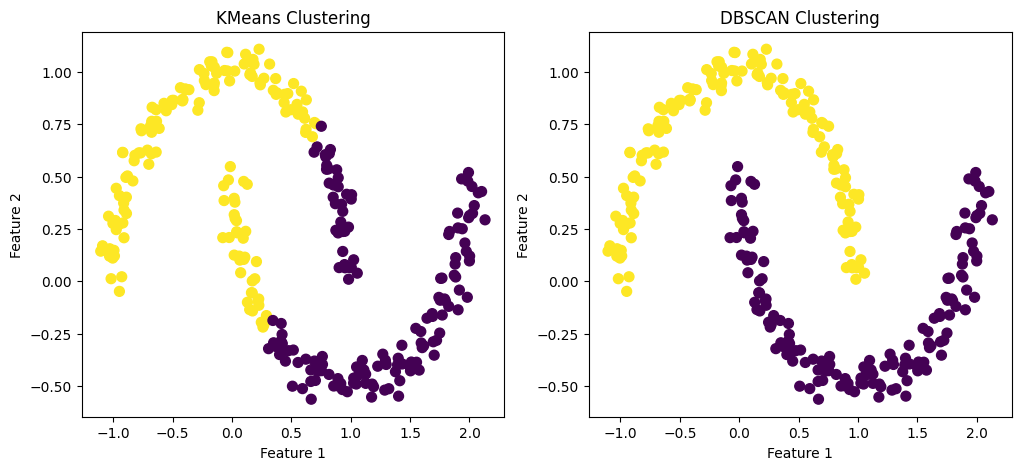

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons

# Generate sample data with non-spherical clusters
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# Step 1: Apply KMeans for comparison
kmeans = KMeans(n_clusters=2)
kmeans_labels = kmeans.fit_predict(X)

# Plot KMeans clustering results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=50)
plt.title('KMeans Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Step 2: Apply DBSCAN with chosen parameters
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Plot DBSCAN clustering results
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis', s=50)
plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Explanation of the Example

1. **Dataset**: We generate a "two moons" dataset, which has two interlocking crescent shapes. This structure is difficult for algorithms like KMeans, which assume spherical clusters.
2. **KMeans Clustering**: KMeans attempts to cluster the data into two groups but struggles to capture the complex shapes, forcing clusters into roughly circular boundaries.
3. **DBSCAN Clustering**: DBSCAN successfully identifies the two crescent-shaped clusters. It does not assume spherical clusters, making it well-suited for this type of data. DBSCAN also identifies any points that do not fit well into the clusters as noise (outliers).


## Anomaly Detection

### What is Anomaly Detection?
Anomaly Detection is the process of identifying unusual patterns or data points that do not conform to the expected behavior in a dataset. These unusual data points, known as **anomalies** or **outliers**, could represent critical insights, such as fraud in financial transactions, network intrusions, or defects in manufacturing.

Anomaly detection is commonly used in various fields, including:
- **Finance**: Detecting fraudulent transactions.
- **Cybersecurity**: Identifying malicious network activity or intrusions.
- **Healthcare**: Recognizing unusual medical conditions in patient data.
- **Manufacturing**: Detecting equipment malfunctions through sensor data.

### Types of Anomalies
1. **Point Anomalies**: Individual data points that significantly differ from the rest of the dataset. For example, a sudden spike in a transaction amount.
2. **Contextual Anomalies**: Data points that are unusual in a specific context, like an unusually high temperature in winter.
3. **Collective Anomalies**: A group of data points that are normal on their own but anomalous when viewed together, such as a sequence of actions leading to a security breach.

---

### Why Use Unsupervised Learning for Anomaly Detection?

In many real-world applications, labeled data indicating normal or anomalous behavior is scarce or non-existent. **Unsupervised learning** is a valuable approach in such cases because it can identify patterns in data without relying on predefined labels.

#### How Unsupervised Learning Detects Anomalies
Unsupervised learning techniques focus on understanding the structure of the data to identify deviations. Some commonly used unsupervised approaches include:

1. **Density-Based Methods**:
   - Techniques like **DBSCAN** and **LOF (Local Outlier Factor)** assume that normal data points occur in dense regions, while anomalies are isolated or in low-density areas.
   - **Example**: In a dataset of network traffic, most data points (normal traffic) will be densely packed, while unusual traffic patterns (potential intrusions) will appear in sparse regions.

2. **Clustering-Based Methods**:
   - Algorithms like **K-Means** and **Hierarchical Clustering** can be used for anomaly detection. Data points that do not fit well into any cluster or fall far from cluster centroids may be considered anomalies.
   - **Example**: In customer segmentation, typical customers form clusters based on buying behavior, and any data points far from these clusters might indicate unusual behavior.

3. **Distance-Based Methods**:
   - These methods detect anomalies by calculating the distance between data points. Points far from their neighbors are likely to be anomalies.
   - **Example**: In credit card transactions, unusually large transactions could appear as distant points when calculating distances in the dataset.

4. **Reconstruction-Based Methods**:
   - Methods like **Autoencoders** learn to reconstruct data points efficiently. Points that the model struggles to reconstruct well are likely anomalous.
   - **Example**: In machine sensor data, an autoencoder trained on normal behavior can detect faults or anomalies if it fails to reconstruct abnormal data patterns.

---

### Advantages of Unsupervised Learning for Anomaly Detection
- **No need for labeled data**: Useful when anomalies are rare or labels are unavailable.
- **Adaptability to changing data**: Many unsupervised methods can dynamically adapt to new patterns in the data, making them suitable for dynamic environments.
- **Applicability to diverse domains**: Works well in fields where defining anomalies beforehand is challenging, such as cybersecurity or finance.




## Nearest Neighbor for Anomaly Detection

### Overview
The **Nearest Neighbor** method is a straightforward yet effective approach for anomaly detection. It works by examining the distance of a data point from its nearest neighbors. Points that are far from their neighbors are considered **anomalies** or **outliers**. This approach assumes that normal points occur in dense regions of the data, while anomalies appear isolated or far from other points.

### Key Concepts

1. **k-Nearest Neighbors (k-NN)**:
   - The **k-NN anomaly detection** approach calculates the distance between each point and its $ k $ nearest neighbors.
   - For each data point $ x_i $, we compute the **average distance** or **maximum distance** to its $ k $ nearest neighbors.
   - A threshold is set for determining anomalies: if the distance of $ x_i $ from its neighbors exceeds this threshold, it is flagged as an anomaly.

2. **Distance Calculation**:
   - The most common distance metric used in k-NN is the **Euclidean Distance**:
     $$
     d(x_i, x_j) = \sqrt{\sum_{k=1}^n (x_{ik} - x_{jk})^2}
     $$
   - For each data point $ x_i $, the **anomaly score** can be calculated as:
     $$
     \text{Anomaly Score}(x_i) = \frac{1}{k} \sum_{j=1}^{k} d(x_i, x_j)
     $$
     where $ x_j $ are the $ k $ nearest neighbors of $ x_i $.

3. **Setting a Threshold**:
   - A threshold is defined to distinguish between normal points and anomalies. Points with an anomaly score higher than this threshold are flagged as anomalies.




/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


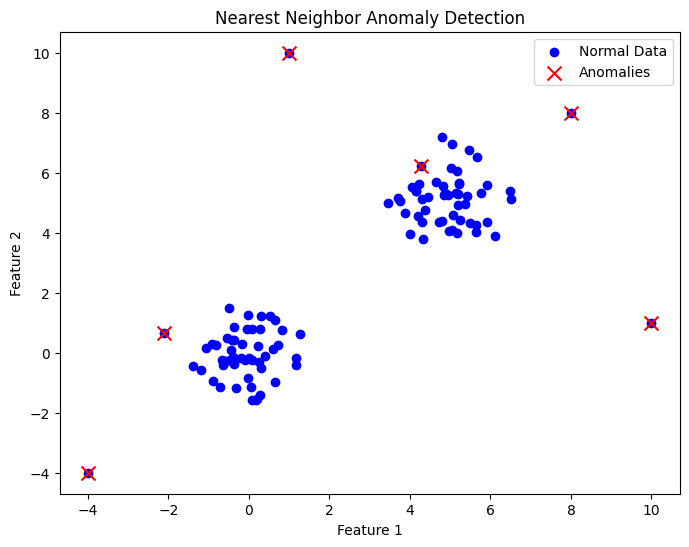

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.datasets import make_blobs

# Generate sample data with two clusters
X, _ = make_blobs(n_samples=100, centers=[[0, 0], [5, 5]], cluster_std=0.8, random_state=42)

# Adding some anomalies
X = np.vstack([X, [[8, 8], [-4, -4], [10, 1], [1, 10]]])

# Step 1: Fit Nearest Neighbors model
k = 3  # Number of neighbors
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X)

# Step 2: Calculate anomaly scores (average distance to k nearest neighbors)
distances, _ = nbrs.kneighbors(X)
anomaly_scores = distances.mean(axis=1)

# Step 3: Define a threshold for anomaly detection
threshold = np.percentile(anomaly_scores, 95)  # Top 5% as anomalies
anomalies = anomaly_scores > threshold

# Step 4: Plot results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', label="Normal Data")
plt.scatter(X[anomalies, 0], X[anomalies, 1], c='red', label="Anomalies", marker="x", s=100)
plt.title('Nearest Neighbor Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()



### Explanation of the Example

1. **Data Generation**: We create a dataset with two distinct clusters and add a few points that act as anomalies.
2. **Nearest Neighbors Model**: We fit a Nearest Neighbors model with $ k = 3 $ to calculate the average distance to each point’s 3 nearest neighbors.
3. **Anomaly Score Calculation**: We compute the anomaly score for each point as the mean distance to its 3 nearest neighbors.
4. **Threshold and Anomalies**: We set a threshold based on the 95th percentile of the anomaly scores, treating points with scores above this threshold as anomalies.
5. **Visualization**: Points classified as anomalies are marked in red, showing

## Isolation Forest for Anomaly Detection

### Overview
**Isolation Forest** is an efficient and powerful anomaly detection algorithm that works by isolating observations. Unlike distance-based methods, which rely on density, Isolation Forest explicitly isolates anomalies by recursively partitioning the data. Anomalies are easier to isolate since they tend to appear in low-density regions, far from other points.

Isolation Forest is particularly well-suited for high-dimensional datasets and is computationally efficient because of its tree-based structure.

### Key Concepts in Isolation Forest

1. **Isolation Trees (iTrees)**:
   - Isolation Forest consists of multiple **isolation trees**. Each tree is built by randomly selecting a feature and a split value to partition the data.
   - This process continues recursively, isolating each observation until it reaches a leaf node.

2. **Path Length**:
   - The number of splits required to isolate a point is called its **path length**.
   - Anomalies are expected to have **shorter path lengths** because they are isolated faster than normal points.

3. **Anomaly Score**:
   - The anomaly score is based on the average path length across all trees. For an observation $ x $, the anomaly score $ s(x, n) $ is calculated as:
     $$
     s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}
     $$
     where:
     - $ h(x) $ is the path length of $ x $.
     - $ E(h(x)) $ is the average path length of $ x $ across all trees.
     - $ c(n) $ is the average path length of a normal point for a sample of size $ n $, which helps normalize the score.

   - A score close to 1 indicates an anomaly, while a score close to 0 suggests a normal observation.

---

### Usage of Isolation Forest
Isolation Forest is widely used for anomaly detection in:
- **Credit Card Fraud Detection**: Identifying fraudulent transactions by isolating unusual spending patterns.
- **Network Intrusion Detection**: Detecting intrusions in network traffic based on patterns that deviate from normal activity.
- **Equipment Failure Prediction**: Monitoring sensor data to detect early signs of equipment failure in manufacturing.


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


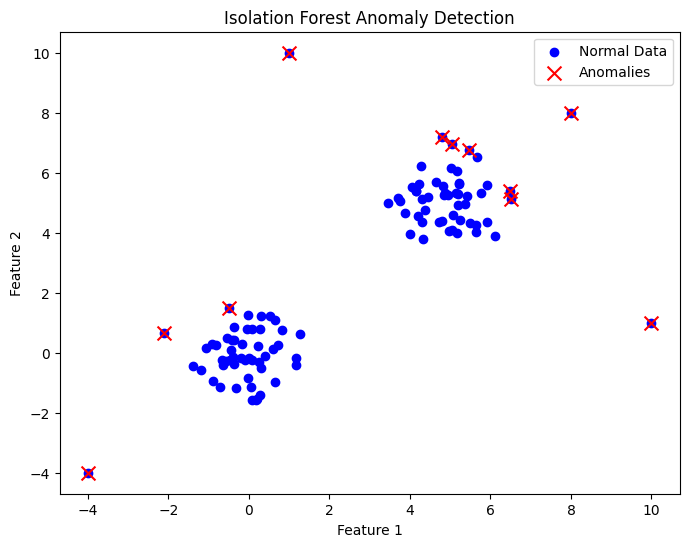

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

# Generate sample data with two clusters
X, _ = make_blobs(n_samples=100, centers=[[0, 0], [5, 5]], cluster_std=0.8, random_state=42)

# Adding some anomalies
X = np.vstack([X, [[8, 8], [-4, -4], [10, 1], [1, 10]]])

# Step 1: Fit Isolation Forest model
iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_forest.fit(X)

# Step 2: Predict anomalies (returns -1 for anomalies, 1 for normal points)
predictions = iso_forest.predict(X)
anomalies = predictions == -1

# Step 3: Plot results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', label="Normal Data")
plt.scatter(X[anomalies, 0], X[anomalies, 1], c='red', label="Anomalies", marker="x", s=100)
plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()



### Explanation of the Example

1. **Data Generation**: We create a dataset with two clusters and add a few points that act as anomalies.
2. **Isolation Forest Model**: We fit an Isolation Forest model with a contamination rate of 0.1, meaning that 10% of the data is expected to be anomalies.
3. **Prediction**: The model predicts anomalies (labelled as -1) and normal points (labelled as 1).
4. **Visualization**: Points classified as anomalies are marked in red, while normal points are shown in blue.

Isolation Forest quickly identifies the isolated, low-density points as anomalies, demonstrating its effectiveness in detecting outliers based on isolation rather than density.